In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [17]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [18]:
feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target_col = "species"

df_ml = df[feature_cols + [target_col]].dropna()

X = df_ml[feature_cols]
y = df_ml[target_col]

df_ml.shape, y.value_counts()

((342, 5),
 species
 Adelie       151
 Gentoo       123
 Chinstrap     68
 Name: count, dtype: int64)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((273, 4), (69, 4))

In [20]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=200))
    ]),
    "kNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

In [21]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print("=", name, "=")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    print()

results

= Logistic Regression =
Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


= kNN (k=5) =
Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


= Decision Tree =
Accuracy: 1.0
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      

[('Logistic Regression', 1.0), ('kNN (k=5)', 1.0), ('Decision Tree', 1.0)]

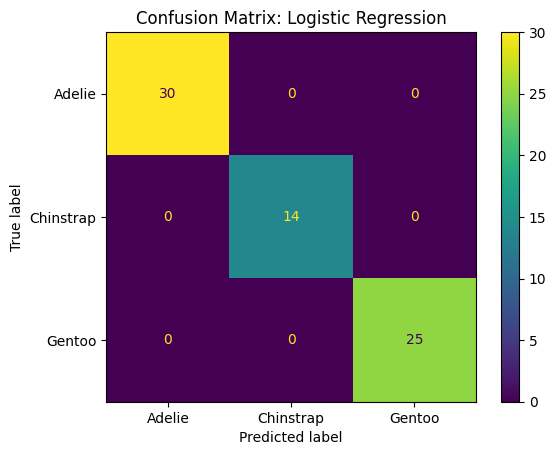

('Logistic Regression', 1.0)

In [22]:
best_name, best_acc = sorted(results, key=lambda x: x[1], reverse=True)[0]
best_model = models[best_name]

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_ if hasattr(best_model, "classes_") else np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot()
plt.title(f"Confusion Matrix: {best_name}")
plt.show()

best_name, best_acc

## Interpretation

- We used a classification task: predicting **penguin species** from numeric measurements.
- We trained and evaluated three classifiers: Logistic Regression, kNN, and Decision Tree.
- Performance was assessed using accuracy and the classification report (precision/recall/F1), plus a confusion matrix.

### Strengths
- Simple models perform well on this structured dataset.
- Scaling improves models like Logistic Regression and kNN.

### Limitations
- Dataset is relatively small.
- We used only basic hyperparameters (no tuning/cross-validation).
- Dropping missing values reduces the number of samples.

### Next steps
- Hyperparameter tuning with cross-validation (GridSearchCV).
- Try additional models (Random Forest, SVM).
- Use feature importance (tree-based models) for explainability.